## **Parte I: Familiarinzandonos con la base EPH y limipieza**

### **Punto 1** 

El INDEC identifica a las personas pobres en Argentina a partir de la medición de la pobreza por ingresos. El procedimiento se basa en comparar los ingresos del hogar con el costo de la Canasta Básica Total (CBT):

Canasta Básica Alimentaria (CBA): define la línea de indigencia. Incluye solo alimentos que cubren un umbral mínimo de necesidades energéticas y proteicas. Un hogar es indigente si sus ingresos no alcanzan para cubrir la CBA.

Canasta Básica Total (CBT): amplía la CBA incorporando bienes y servicios no alimentarios (vestimenta, transporte, educación, salud, etc.).Un hogar es pobre no indigente si sus ingresos superan la CBA pero no alcanzan la CBT. 

### **Punto 2**

Entren a la página https://www.indec.gob.ar/ y vayan a la sección
Servicios y Herramientas → Bases de datos. Descarguen la base de
microdatos de la Encuesta Permanente de Hogares (EPH)
correspondiente al primer trimestre de 2005 y 2025 en formato .dta y
.xls, respectivamente (una vez descargadas, las bases a usar deberán
llamarse usu_individual_T105.dta y
usu_individual_T125.xls). En la página web, también encontrará
un diccionario de variables con el nombre de “Diseño de registro y
estructura para las bases preliminares (hogares y personas)”.
Descarguen el diccionario de cada año (los de 2005 y 2025). En estos
archivos se les indica qué significa cada variable que aparece en la
base de datos, en particular, en la sección de Diseño de registros de la
base Personas.

a. A partir de ahora, cada grupo debe decidir trabajar con una
región del país en específico y mantener dicha región en los
próximos trabajos prácticos (ver variable REGION). Eliminen los
datos de todas aquellas regiones que no se encuentren dentro
de su región y unan ambos trimestres (2005 y 2025) en una
sola base.

b. Asegúrense de que todas las variables tengan el formato
correcto. Seleccione 15 variables de interés (entre las
cuales tienen que estar: CH04, CH06, CH07, CH08,
NIVEL ED, ESTADO, CAT_INAC, IPCF) y reporten en una
figura de heatmap la cantidad de valores faltantes para cada
año (NA, o NaN en Python) en una tabla por cada año.
Comenten qué variables de las 15 que seleccionaron tienen más
valores faltantes y qué año.

c. Corregir variables si notan valores sin sentido (como ingresos
negativos) de acuerdo a la documentación de la EPH (puede ser una codificación de no respuesta de los individuos) y eliminen
estos valores extraños de sus 15 variables de interés. Comenten
brevemente en el reporte dicho proceso de limpieza.

In [1]:
import pandas as pd
import os

In [2]:
#Cambié a como estaba porque no me leía el archivo la verga esta
# reemplazar x la ruta de cada uno
df = pd.read_excel("C:/Users/loloa/OneDrive/Escritorio/facu/Ciencia de datos/tp/Ciencia-de-Datos/usu_individual_T125.xlsx") 

print(df.head())

                          CODUSU  ANO4  TRIMESTRE  NRO_HOGAR  COMPONENTE  H15  \
0  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           2    1   
1  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           3    0   
2  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           4    0   
3  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           5    0   
4  TQRMNOUPQHLOLOCDEFKID00851757  2025          1          1           1    1   

   REGION MAS_500  AGLOMERADO  PONDERA  ...  V21_03_M  V22_01_M V22_02_M  \
0      43       S           4      927  ...         0         0        0   
1      43       S           4      927  ...         0         0        0   
2      43       S           4      927  ...         0         0        0   
3      43       S           4      927  ...         0         0        0   
4      43       S           4     1294  ...         0         0        0   

   V22_03_M  P_DECCF  P_RDECCF  P_GDECCF  P_PDECCF  P_ID

In [3]:
statta = pd.read_stata("Individual_t105.dta")
print(statta.head())


     CODUSU  nro_hogar componente  h15    ano4       trimestre  \
0  125098          1.0        1.0   Sí  2005.0  1er. Trimestre   
1  125188          1.0        1.0   Sí  2005.0  1er. Trimestre   
2  125188          1.0        2.0   Sí  2005.0  1er. Trimestre   
3  125188          1.0        3.0  0.0  2005.0  1er. Trimestre   
4  125242          1.0        1.0   Sí  2005.0  1er. Trimestre   

              region mas_500              aglomerado  pondera  ... deccfr  \
0  Gran Buenos Aires       S  Ciudad de Buenos Aires   1017.0  ...     08   
1  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
2  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
3  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
4  Gran Buenos Aires       S  Ciudad de Buenos Aires   1103.0  ...     09   

  ideccfr rdeccfr gdeccfr pdeccfr adeccfr pj1_1 pj2_1 pj3_1 idimpp  
0              07      08              05   0.0   0.0   0.0  00000  
1 

In [4]:
print(statta.columns)  # Mostrar las columnas del DataFrame
print(statta.shape)    # Mostrar la forma del DataFrame (filas, columnas)
print(statta["region"].unique())


Index(['CODUSU', 'nro_hogar', 'componente', 'h15', 'ano4', 'trimestre',
       'region', 'mas_500', 'aglomerado', 'pondera',
       ...
       'deccfr', 'ideccfr', 'rdeccfr', 'gdeccfr', 'pdeccfr', 'adeccfr',
       'pj1_1', 'pj2_1', 'pj3_1', 'idimpp'],
      dtype='object', length=176)
(47030, 176)
['Gran Buenos Aires', 'NOA', 'NEA', 'Cuyo', 'Pampeana', 'Patagónica']
Categories (6, object): ['Gran Buenos Aires' < 'NOA' < 'NEA' < 'Cuyo' < 'Pampeana' < 'Patagónica']


In [5]:
print(df.columns)  # Mostrar las columnas del DataFrame
print(df.shape)    # Mostrar la forma del DataFrame (filas, columnas)
print(df["REGION"].unique()) 
#43 es pampeana


Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15',
       'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA',
       ...
       'V21_03_M', 'V22_01_M', 'V22_02_M', 'V22_03_M', 'P_DECCF', 'P_RDECCF',
       'P_GDECCF', 'P_PDECCF', 'P_IDECCF', 'P_ADECCF'],
      dtype='object', length=235)
(45425, 235)
[43 41 42 40 44  1]


In [6]:
#Nos quedamos solo con la región pampeana
df_pampeana2025 = df[df['REGION'] == 43]
print(df_pampeana2025.head())

statta_pampeana2005 = statta[statta['region'] =="Pampeana"]
print(statta_pampeana2005.head())

                          CODUSU  ANO4  TRIMESTRE  NRO_HOGAR  COMPONENTE  H15  \
0  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           2    1   
1  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           3    0   
2  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           4    0   
3  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           5    0   
4  TQRMNOUPQHLOLOCDEFKID00851757  2025          1          1           1    1   

   REGION MAS_500  AGLOMERADO  PONDERA  ...  V21_03_M  V22_01_M V22_02_M  \
0      43       S           4      927  ...         0         0        0   
1      43       S           4      927  ...         0         0        0   
2      43       S           4      927  ...         0         0        0   
3      43       S           4      927  ...         0         0        0   
4      43       S           4     1294  ...         0         0        0   

   V22_03_M  P_DECCF  P_RDECCF  P_GDECCF  P_PDECCF  P_ID

In [7]:
df_pampeana2025.columns = df_pampeana2025.columns.str.lower()
print(df_pampeana2025.head())

                          codusu  ano4  trimestre  nro_hogar  componente  h15  \
0  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           2    1   
1  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           3    0   
2  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           4    0   
3  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           5    0   
4  TQRMNOUPQHLOLOCDEFKID00851757  2025          1          1           1    1   

   region mas_500  aglomerado  pondera  ...  v21_03_m  v22_01_m v22_02_m  \
0      43       S           4      927  ...         0         0        0   
1      43       S           4      927  ...         0         0        0   
2      43       S           4      927  ...         0         0        0   
3      43       S           4      927  ...         0         0        0   
4      43       S           4     1294  ...         0         0        0   

   v22_03_m  p_deccf  p_rdeccf  p_gdeccf  p_pdeccf  p_id

In [8]:
columns_to_check = ['ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf']

print("Unique values in df_pampeana2025:")
for col in columns_to_check:
    if col in df_pampeana2025.columns:
        print(f"{col}: {df_pampeana2025[col].unique()}")
    else:
        print(f"{col}: Column not found in df_pampeana2025")

print("\nUnique values in statta_pampeana2005:")
for col in columns_to_check:
    if col in statta_pampeana2005.columns:
        print(f"{col}: {statta_pampeana2005[col].unique()}")
    else:
        print(f"{col}: Column not found in statta_pampeana2005")
    

Unique values in df_pampeana2025:
ch04: [2 1]
ch06: [ 25   7   4  -1  29  13   5  39  41   2  51  28  24  19  49  58  23  22
  68  60  47  42  44  37  35  12  11  10  53  16  78  61  62  63  14   8
  27  26  20  31  43  59  21  34  81  32  30  75  76  33  15  55  65  73
  52  56  48  40  57  66  36  86  80  72  74  79  45  87  82  64  38   6
   3  71   9  46  17  18   1  90  77  67  54  84  50  69  89  70  85  92
  83  88  93  91  97 102  95 101  94  96]
ch07: [1 5 2 4 3]
ch08: [  4.   1.   2.   3.  12. 123.   9.  13.]
nivel_ed: [4 1 7 5 6 3 2]
estado: [1 4 3 2 0]
cat_inac: [0 3 5 4 1 6 2 7]
ipcf: [ 205600.    230000.    350000.   ...   36666.67 1037500.    616000.  ]

Unique values in statta_pampeana2005:
ch04: ['Varón', 'Mujer']
Categories (2, object): ['Varón' < 'Mujer']
ch06: [28.0, 30.0, 4.0, 66.0, 60.0, ..., '98 y más años', 90.0, 95.0, 94.0, 97.0]
Length: 99
Categories (99, object): ['Menos de 1 año' < 1.0 < 2.0 < 3.0 ... 95.0 < 96.0 < 97.0 < '98 y más años']
ch07: ['Casado', 'S

In [9]:
# el prompt: from ch04 in statta_pampeana2005 , transform "Varón" to 1 and "Mujer" to 2
statta_pampeana2005['ch04'] = statta_pampeana2005['ch04'].replace({'Varón': 1, 'Mujer': 2})
statta_pampeana2005['ch04'].dtype

C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2632009088.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  statta_pampeana2005['ch04'] = statta_pampeana2005['ch04'].replace({'Varón': 1, 'Mujer': 2})
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2632009088.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  statta_pampeana2005['ch04'] = statta_pampeana2005['ch04'].replace({'Varón': 1, 'Mujer': 2})
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2632009088.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

CategoricalDtype(categories=[1, 2], ordered=True, categories_dtype=int64)

In [10]:
#ch06. valores: edad. 1 a 100
only_in_statta = set(statta_pampeana2005["ch06"].unique()) - set(df_pampeana2025["ch06"].unique())
print("Values only in statta_pampeana2005['ch06']:", only_in_statta)

only_in_df = set(df_pampeana2025["ch06"].unique()) - set(statta_pampeana2005["ch06"].unique())
print("Values only in df_pampeana2025['ch06']:", only_in_df)



Values only in statta_pampeana2005['ch06']: {'98 y más años', 'Menos de 1 año'}
Values only in df_pampeana2025['ch06']: {np.int64(101), np.int64(102), np.int64(-1)}


In [11]:
statta_pampeana2005['ch06'] = statta_pampeana2005['ch06'].replace('Menos de 1 año', -1)
statta_pampeana2005["ch06"] = statta_pampeana2005["ch06"].replace("98 y más años",98)
#aca no se si cortar en 97 en los 2 para que quede igual, o dejarlo asi.
#por ahora lo hago y de ultima lo dejamos como comentario
statta_pampeana2005 = statta_pampeana2005[statta_pampeana2005["ch06"].astype(float) <= 97]
df_pampeana2025 = df_pampeana2025[df_pampeana2025["ch06"].astype(float) <= 97]


C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2186132469.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  statta_pampeana2005['ch06'] = statta_pampeana2005['ch06'].replace('Menos de 1 año', -1)
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2186132469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  statta_pampeana2005['ch06'] = statta_pampeana2005['ch06'].replace('Menos de 1 año', -1)
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2186132469.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will 

In [12]:
d2005=statta_pampeana2005
d2025=df_pampeana2025

print("Are the unique values equal?", set(d2005["ch06"].unique()) == set(d2025["ch06"].unique()))
#listo ch06

Are the unique values equal? True


In [13]:
#ch07... 1=unido 2= casado 3=separado 4=viudo 5=soltero
#['Casado', 'Soltero', 'Unido', 'Viudo', 'Separado o divorciado', 'Ns./Nr.']
#saco las filas con ns/nr



d2005 = d2005[d2005['ch07'] != 'Ns./Nr.']
d2005['ch07'] = d2005['ch07'].replace({
    'Unido': 1,
    'Casado': 2,
    'Separado o divorciado': 3,
    'Viudo': 4,
    'Soltero': 5
})
print("Are the unique values equal?", set(d2005["ch07"].unique()) == set(d2025["ch07"].unique()))

Are the unique values equal? True


C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\409446041.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005['ch07'] = d2005['ch07'].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\409446041.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005['ch07'] = d2005['ch07'].replace({


In [14]:
d2005['ch08'] = d2005['ch08'].replace({
    'No paga ni le descuentan': 4,
    'Obra social (incluye PAMI)': 1,
    'Mutual/Prepaga/Servicio de emergencia': 2,
    'Obra social y mutual/prepaga/servicio de emergencia': 12,
    'Obra social y planes y seguros públicos': 13,
    'Obra social, mutual/prepaga/servicio de emergencia y planes': 123,
    'Planes y seguros públicos': 3,
    'Mutual/prepaga/servicio de emergencia/planes y seguros públi': 23,
    'Ns./Nr.': 9
})
d2025["ch08"] = d2025["ch08"].astype('Int64')

print(d2025["ch08"].unique())
print(d2005["ch08"].unique())
#es medio confuso porque falta el 23 en el d2025 pero estan de igual formato


<IntegerArray>
[4, 1, 2, 3, 12, 123, 9, 13]
Length: 8, dtype: Int64
[4, 1, 2, 12, 13, 123, 3, 23, 9]
Categories (9, int64): [1 < 2 < 3 < 4 ... 12 < 13 < 23 < 123]


C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\3293158098.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d2005['ch08'] = d2005['ch08'].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\3293158098.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005['ch08'] = d2005['ch08'].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\3293158098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

In [15]:

d2005["cat_inac"] = d2005["cat_inac"].replace({
    "Jubilado/pensionado": 1,
    "Rentista": 2,
    "Estudiante": 3,
    "Ama de casa": 4,
    "Menor de 6 años": 5,
    "Discapacitado": 6,
    "Otros": 7
})

#el d2005 tambien tiene un 0, a priori lo borro pq no tiene significado lo pueden revertir haciendo comentario la linea d abajo
d2005 = d2005[d2005["cat_inac"] != 0]
print(d2005["cat_inac"].unique())


C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\1253168025.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d2005["cat_inac"] = d2005["cat_inac"].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\1253168025.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005["cat_inac"] = d2005["cat_inac"].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\1253168025.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

[5.0, 1.0, 3.0, 4.0, 2.0, 6.0, 7.0]
Categories (8, float64): [0.0 < 1.0 < 2.0 < 3.0 < 4.0 < 5.0 < 6.0 < 7.0]


In [16]:
#ipcf. esta en pesos, supongo que lo ajusto por infla

print("d2005 ipcf min:", d2005["ipcf"].min(), "max:", d2005["ipcf"].max())
print("d2025 ipcf min:", d2025["ipcf"].min(), "max:", d2025["ipcf"].max())


#le aplico la inflacion marzo 2005-marzo 2025
if not hasattr(d2005, "_ipcf_adjusted"):
    d2005["ipcf"] = d2005["ipcf"] * 969.61  # ajuste por inflación aproximado
    d2005._ipcf_adjusted = True

print("d2005 ipcf min:", d2005["ipcf"].min(), "max:", d2005["ipcf"].max())
print("d2025 ipcf min:", d2025["ipcf"].min(), "max:", d2025["ipcf"].max())


#debería andar

d2005 ipcf min: 0.0 max: 7500.0
d2025 ipcf min: 0.0 max: 8600000.0
d2005 ipcf min: 0.0 max: 7272075.0
d2025 ipcf min: 0.0 max: 8600000.0


In [17]:
d2005["nivel_ed"] = d2005["nivel_ed"].replace({
    'Primaria Completa': 2,
    'Superior Universitaria Completa': 6,
    'Sin instrucción': 7,
    'Secundaria Incompleta': 3,
    'Superior Universitaria Incompleta': 5,
    'Secundaria Completa': 4,
    'Primaria Incompleta (incluye educación especial)': 1
})

print("Valores únicos en df_pampeana2005['nivel_ed']:")
print(d2005["nivel_ed"].unique)
print(d2025["nivel_ed"].unique())
# Verificar si todos los valores únicos de d2005["nivel_ed"] están en d2025["nivel_ed"]
valores_d2005 = set(d2005["nivel_ed"].dropna().unique())
valores_d2025 = set(d2025["nivel_ed"].dropna().unique())
todos_en_2025 = valores_d2005.issubset(valores_d2025)
print("¿Todos los valores únicos de d2005['nivel_ed'] están en d2025['nivel_ed']?:", todos_en_2025)
print("Valores en d2005 y no en d2025:", valores_d2005 - valores_d2025)

Valores únicos en df_pampeana2005['nivel_ed']:
<bound method Series.unique of 29152    7
29159    7
29165    6
29167    3
29170    7
        ..
43795    3
43796    3
43797    1
43798    5
43800    5
Name: nivel_ed, Length: 8135, dtype: category
Categories (7, int64): [1 < 2 < 3 < 4 < 5 < 6 < 7]>
[4 1 7 5 6 3 2]
¿Todos los valores únicos de d2005['nivel_ed'] están en d2025['nivel_ed']?: True
Valores en d2005 y no en d2025: set()


C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2612755933.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d2005["nivel_ed"] = d2005["nivel_ed"].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\2612755933.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005["nivel_ed"] = d2005["nivel_ed"].replace({


Variable CH09

In [18]:
print("d2005:", d2005["ch09"].dtype)
print("d2025:", d2025["ch09"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch09"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch09"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['No', 'Menor de 2 años', 'Sí']
Categories (5, object): [0.0 < 'Sí' < 'No' < 'Menor de 2 años' < 'Ns./Nr.']

Valores únicos en d2025:
[1 2 3]


In [19]:
# Definir un diccionario de mapeo
map_ch09 = {
    'Sí': 1,
    'No': 2,
    'Menor de 2 años': 3,
    'Ns./Nr.': pd.NA  # lo dejamos como valor faltante
}

# Convertir d2005["ch09"] a int usando el mapeo
d2005["ch09"] = d2005["ch09"].map(map_ch09).astype('Int64')  # Int64 permite NA

# Verificamos
print(d2005["ch09"].dtype)
print(d2005["ch09"].unique())


Int64
<IntegerArray>
[2, 3, 1]
Length: 3, dtype: Int64


In [20]:
# Revisar tipo de dato
print("Tipo d2005['ch09']:", d2005['ch09'].dtype)
print("Tipo d2025['ch09']:", d2025['ch09'].dtype)

# Revisar valores únicos ordenados
print("\nValores únicos d2005['ch09']:", sorted(d2005['ch09'].dropna().unique()))
print("Valores únicos d2025['ch09']:", sorted(d2025['ch09'].dropna().unique()))

# Comparar si los valores únicos coinciden
valores_comunes = set(d2005['ch09'].dropna().unique()) == set(d2025['ch09'].dropna().unique())
print("\n¿Tienen las mismas categorías numéricas?", valores_comunes)


Tipo d2005['ch09']: Int64
Tipo d2025['ch09']: int64

Valores únicos d2005['ch09']: [np.int64(1), np.int64(2), np.int64(3)]
Valores únicos d2025['ch09']: [np.int64(1), np.int64(2), np.int64(3)]

¿Tienen las mismas categorías numéricas? True


Variable CH10

In [21]:
print("d2005:", d2005["ch10"].dtype)
print("d2025:", d2025["ch10"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch10"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch10"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['Sí, asiste', 0.0, 'No asiste, pero asistió', 'Nunca asistió']
Categories (5, object): [0.0 < 'Sí, asiste' < 'No asiste, pero asistió' < 'Nunca asistió' < 'Ns./Nr.']

Valores únicos en d2025:
[2 1 0 3]


In [22]:
# Definir mapeo de d2005 a números
map_ch10 = {
    'Sí, asiste': 1,
    'No asiste, pero asistió': 2,
    'Nunca asistió': 3,
    'Ns./Nr.': pd.NA,
    0.0: pd.NA  # en caso de que aparezca 0.0
}

# Aplicar el mapeo
d2005["ch10"] = d2005["ch10"].map(map_ch10).astype('Int64')

# Asegurarse de que d2025 también sea Int64
d2025["ch10"] = d2025["ch10"].astype('Int64')


In [23]:
d2025["ch10"] = d2025["ch10"].replace(0, pd.NA).astype('Int64')
# Verificación
print("d2005['ch10'] dtype:", d2005["ch10"].dtype)
print("d2025['ch10'] dtype:", d2025["ch10"].dtype)

print("\nValores únicos d2005['ch10']:", sorted(d2005["ch10"].dropna().unique()))
print("Valores únicos d2025['ch10']:", sorted(d2025["ch10"].dropna().unique()))

d2005['ch10'] dtype: Int64
d2025['ch10'] dtype: Int64

Valores únicos d2005['ch10']: [np.int64(1), np.int64(2), np.int64(3)]
Valores únicos d2025['ch10']: [np.int64(1), np.int64(2), np.int64(3)]


CH03

In [24]:
print("d2005:", d2005["ch03"].dtype)
print("d2025:", d2025["ch03"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch03"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch03"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['Hijo/Hijastro', 'Jefe', 'Hermano', 'Cónyuge/Pareja', 'Nieto', 'No familiares', 'Yerno/Nuera', 'Suegro', 'Otros familiares', 'Madre/Padre']
Categories (10, object): ['Jefe' < 'Cónyuge/Pareja' < 'Hijo/Hijastro' < 'Yerno/Nuera' ... 'Suegro' < 'Hermano' < 'Otros familiares' < 'No familiares']

Valores únicos en d2025:
[ 2  3  1  5  9  4  6  8 10  7]


In [25]:
# Definir mapeo de d2005 a números según d2025
map_ch03 = {
    'Jefe': 1,
    'Cónyuge/Pareja': 2,
    'Hijo/Hijastro': 3,
    'Yerno/Nuera': 4,
    'Nieto': 5,
    'Madre/Padre': 6,
    'Suegro': 7,
    'Hermano': 8,
    'Otros familiares': 9,
    'No familiares': 10
}

# Aplicar el mapeo
d2005["ch03"] = d2005["ch03"].map(map_ch03).astype('Int64')

# Asegurarse de que d2025 también sea Int64
d2025["ch03"] = d2025["ch03"].astype('Int64')

# Verificación
print("d2005['ch03'] dtype:", d2005["ch03"].dtype)
print("d2025['ch03'] dtype:", d2025["ch03"].dtype)

print("\nValores únicos d2005['ch03']:", sorted(d2005["ch03"].dropna().unique()))
print("Valores únicos d2025['ch03']:", sorted(d2025["ch03"].dropna().unique()))


d2005['ch03'] dtype: Int64
d2025['ch03'] dtype: Int64

Valores únicos d2005['ch03']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Valores únicos d2025['ch03']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


CH14

In [26]:
print("d2005:", d2005["ch14"].dtype)
print("d2025:", d2025["ch14"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch14"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch14"].unique())

d2005: object
d2025: float64
Valores únicos en d2005:
['01' '  ' '02' '03' '08' '00' '06' '99' '05' '07' '04' '98' '09']

Valores únicos en d2025:
[nan  1.  0.  3.  5.  4.  2.  6. 98. 99.  8.  7.  9.]


In [27]:
# Convertir '  ' a NA y el resto a números
d2005["ch14"] = d2005["ch14"].replace({'  ': pd.NA}).astype('Int64')

# Asegurarse de que d2025 también sea Int64
d2025["ch14"] = d2025["ch14"].astype('Int64')

# Verificación
print("d2005['ch14'] dtype:", d2005["ch14"].dtype)
print("d2025['ch14'] dtype:", d2025["ch14"].dtype)

print("\nValores únicos d2005['ch14']:", sorted(d2005["ch14"].dropna().unique()))
print("Valores únicos d2025['ch14']:", sorted(d2025["ch14"].dropna().unique()))


d2005['ch14'] dtype: Int64
d2025['ch14'] dtype: Int64

Valores únicos d2005['ch14']: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98), np.int64(99)]
Valores únicos d2025['ch14']: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98), np.int64(99)]


In [28]:
# Convertir 99 a NA en d2005
d2005["ch14"] = d2005["ch14"].replace('99', pd.NA).astype('Int64')

# Convertir 99 a NA en d2025
d2025["ch14"] = d2025["ch14"].replace(99, pd.NA).astype('Int64')

# Verificación
print("d2005['ch14'] valores únicos:", sorted(d2005["ch14"].dropna().unique()))
print("d2025['ch14'] valores únicos:", sorted(d2025["ch14"].dropna().unique()))


d2005['ch14'] valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98), np.int64(99)]
d2025['ch14'] valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98)]


CH15

In [29]:
print("d2005:", d2005["ch15"].dtype)
print("d2025:", d2025["ch15"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch15"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch15"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['En esta localidad', 'En otra localidad', 'En otro país', 'En otra provincia (especificar)', 'En un país limítrofe', 'Ns./Nr.']
Categories (6, object): ['En esta localidad' < 'En otra localidad' < 'En otra provincia (especificar)' < 'En un país limítrofe' < 'En otro país' < 'Ns./Nr.']

Valores únicos en d2025:
[1 3 2 4 9 5]


In [30]:
# Definir el mapeo según los valores de d2025
map_ch15 = {
    'En esta localidad': 1,
    'En otra localidad': 2,
    'En otra provincia (especificar)': 3,
    'En un país limítrofe': 4,
    'En otro país': 5,
    'Ns./Nr.': pd.NA  # No sabe / No responde
}

# Aplicar el mapeo a d2005 y convertir a Int64
d2005["ch15"] = d2005["ch15"].map(map_ch15).astype('Int64')

# Asegurarnos de que d2025 también sea Int64
d2025["ch15"] = d2025["ch15"].astype('Int64')

# Verificación
print("d2005['ch15'] dtype:", d2005["ch15"].dtype)
print("d2025['ch15'] dtype:", d2025["ch15"].dtype)

print("\nValores únicos d2005['ch15']:", sorted(d2005["ch15"].dropna().unique()))
print("Valores únicos d2025['ch15']:", sorted(d2025["ch15"].dropna().unique()))


d2005['ch15'] dtype: Int64
d2025['ch15'] dtype: Int64

Valores únicos d2005['ch15']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Valores únicos d2025['ch15']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(9)]


In [31]:
d2025["ch15"] = d2025["ch15"].replace(9, pd.NA).astype('Int64')

PP02E

In [32]:
print("d2005:", d2005["pp02e"].dtype)
print("d2025:", d2025["pp02e"].dtype)

print("Valores únicos en d2005:")
print(d2005["pp02e"].unique())

print("\nValores únicos en d2025:")
print(d2025["pp02e"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
[0.0, 'Por otras razones', 'Se cansó de buscar trabajo', 'Hay poco trabajo en esta época del año']
Categories (6, object): [0.0 < 'Está suspendido' < 'Ya tiene trabajo asegurado' < 'Se cansó de buscar trabajo' < 'Hay poco trabajo en esta época del año' < 'Por otras razones']

Valores únicos en d2025:
[0 4 5 3 2]


In [33]:
# Definir mapeo de d2005 a números según d2025
map_pp02e = {
    0.0: pd.NA,  # Si 0.0 significa "No aplica" o "NS/NR"
    'Está suspendido': 1,
    'Ya tiene trabajo asegurado': 2,
    'Se cansó de buscar trabajo': 3,
    'Hay poco trabajo en esta época del año': 4,
    'Por otras razones': 5
}

# Aplicar el mapeo a d2005 y convertir a Int64
d2005["pp02e"] = d2005["pp02e"].map(map_pp02e).astype('Int64')

# Asegurarnos de que d2025 también sea Int64
d2025["pp02e"] = d2025["pp02e"].astype('Int64')

# Verificación
print("d2005['pp02e'] dtype:", d2005["pp02e"].dtype)
print("d2025['pp02e'] dtype:", d2025["pp02e"].dtype)

print("\nValores únicos d2005['pp02e']:", sorted(d2005["pp02e"].dropna().unique()))
print("Valores únicos d2025['pp02e']:", sorted(d2025["pp02e"].dropna().unique()))


d2005['pp02e'] dtype: Int64
d2025['pp02e'] dtype: Int64

Valores únicos d2005['pp02e']: [np.int64(3), np.int64(4), np.int64(5)]
Valores únicos d2025['pp02e']: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


PP02I

In [34]:
print("d2005:", d2005["pp02i"].dtype)
print("d2025:", d2025["pp02i"].dtype)

print("Valores únicos en d2005:")
print(d2005["pp02i"].unique())

print("\nValores únicos en d2025:")
print(d2025["pp02i"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
[0.0, 'No', 'Sí']
Categories (3, object): [0.0 < 'Sí' < 'No']

Valores únicos en d2025:
[0 2 1]


In [35]:
# Definir mapeo de d2005 a números según d2025
map_pp02i = {
    0.0: pd.NA,
    'Sí': 1,
    'No': 2
}

# Aplicar el mapeo a d2005 y convertir a Int64
d2005["pp02i"] = d2005["pp02i"].map(map_pp02i).astype('Int64')

# Asegurar que d2025 sea Int64
d2025["pp02i"] = d2025["pp02i"].astype('Int64')

# Verificación
print("d2005['pp02i'] dtype:", d2005["pp02i"].dtype)
print("d2025['pp02i'] dtype:", d2025["pp02i"].dtype)

print("\nValores únicos d2005['pp02i']:", sorted(d2005["pp02i"].dropna().unique()))
print("Valores únicos d2025['pp02i']:", sorted(d2025["pp02i"].dropna().unique()))


d2005['pp02i'] dtype: Int64
d2025['pp02i'] dtype: Int64

Valores únicos d2005['pp02i']: [np.int64(1), np.int64(2)]
Valores únicos d2025['pp02i']: [np.int64(0), np.int64(1), np.int64(2)]


In [36]:
d2025["pp02i"] = d2025["pp02i"].replace(0, pd.NA).astype('Int64')

In [37]:
print("\nValores únicos d2005['pp02i']:", sorted(d2005["pp02i"].dropna().unique()))
print("Valores únicos d2025['pp02i']:", sorted(d2025["pp02i"].dropna().unique()))


Valores únicos d2005['pp02i']: [np.int64(1), np.int64(2)]
Valores únicos d2025['pp02i']: [np.int64(1), np.int64(2)]


**Armamos la nueva base de datos**

In [38]:
# Lista de columnas que querés unir
columnas = ["ano4", "ch04", "ch06", "ch07", "ch08", "nivel_ed", "estado", 
            "cat_inac", "ipcf", "ch10", "ch03", "ch14", "ch15", 
            "pp02e", "pp02i", "ch09"]

# Verificar cuáles columnas están en cada DataFrame
print("Columnas de d2005 que están en la lista:", [col for col in columnas if col in d2005.columns])
print("Columnas de d2005 que NO están en la lista:", [col for col in columnas if col not in d2005.columns])

print("\nColumnas de d2025 que están en la lista:", [col for col in columnas if col in d2025.columns])
print("Columnas de d2025 que NO están en la lista:", [col for col in columnas if col not in d2025.columns])


Columnas de d2005 que están en la lista: ['ano4', 'ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf', 'ch10', 'ch03', 'ch14', 'ch15', 'pp02e', 'pp02i', 'ch09']
Columnas de d2005 que NO están en la lista: []

Columnas de d2025 que están en la lista: ['ano4', 'ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf', 'ch10', 'ch03', 'ch14', 'ch15', 'pp02e', 'pp02i', 'ch09']
Columnas de d2025 que NO están en la lista: []


In [39]:
# Seleccionamos solo esas columnas en cada DataFrame
d2005_sel = d2005[columnas]
d2025_sel = d2025[columnas]

# Unimos los dos DataFrames por filas (append)
df_combinado = pd.concat([d2005_sel, d2025_sel], ignore_index=True)

# Verificación
print(df_combinado.shape)
print(df_combinado.head())
print(df_combinado.tail())


(21936, 16)
     ano4  ch04  ch06 ch07  ch08  nivel_ed            estado  cat_inac  \
0  2005.0     1   4.0    5     1         7  Menor de 10 años       5.0   
1  2005.0     2   1.0    5    12         7  Menor de 10 años       5.0   
2  2005.0     2  78.0    4     1         6          Inactivo       1.0   
3  2005.0     1  16.0    5     1         3          Inactivo       3.0   
4  2005.0     1  -1.0    5     1         7  Menor de 10 años       5.0   

           ipcf  ch10  ch03  ch14  ch15  pp02e  pp02i  ch09  
0  2.714908e+05     1     3     1     1   <NA>   <NA>     2  
1  3.878440e+05  <NA>     3  <NA>     1   <NA>   <NA>     3  
2  3.102752e+06     2     1  <NA>     1   <NA>      2     1  
3  4.217804e+05     1     3     2     1   <NA>      2     1  
4  5.016116e+05  <NA>     3  <NA>     1   <NA>   <NA>     3  
         ano4  ch04  ch06 ch07  ch08  nivel_ed estado  cat_inac       ipcf  \
21931  2025.0     1  13.0    5     1         3      3       3.0   616000.0   
21932  2025.0  

In [40]:
# Guardar df_combinado como Excel
df_combinado.to_excel("df_combinado.xlsx", index=False)

Valores faltantes:

Tabla de valores faltantes por año y variable:
        ch04  ch06  ch07  ch08  nivel_ed  estado  cat_inac  ipcf  ch10  ch03  \
ano4                                                                           
2005.0     0     0     0     0         0       0         0     0   412     0   
2025.0     0     0     0     0         0       0         0     0   185     0   

        ch14  ch15  pp02e  pp02i  ch09  
ano4                                    
2005.0  3055     1   8053   2274     0  
2025.0  7203     2      0   8011     0  


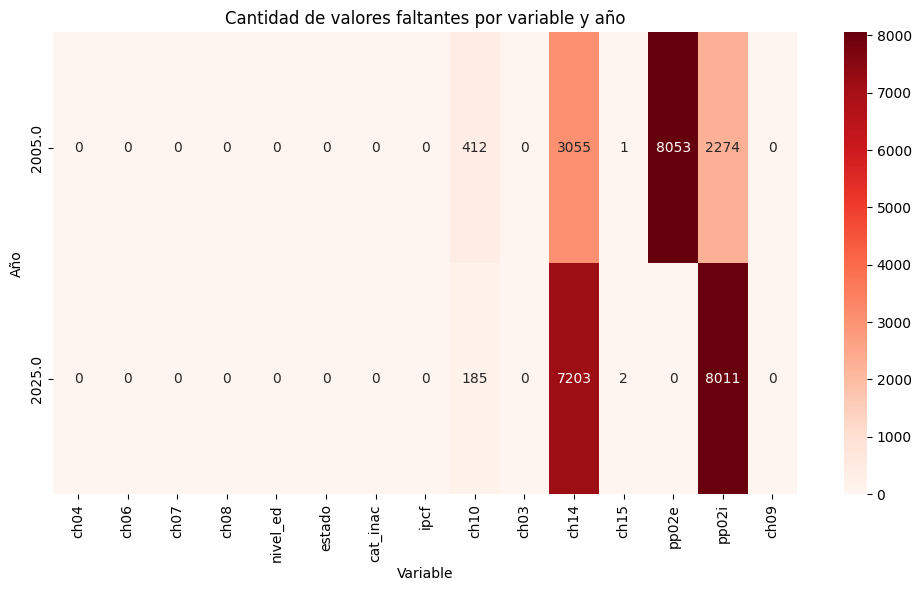

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las 15 variables de interés (excluyendo ano4)
variables = ["ch04", "ch06", "ch07", "ch08", "nivel_ed", "estado", 
             "cat_inac", "ipcf", "ch10", "ch03", "ch14", "ch15", 
             "pp02e", "pp02i", "ch09"]

# Tabla con la cantidad de valores faltantes por variable y año
missing_table = df_combinado.groupby('ano4')[variables].apply(lambda x: x.isna().sum())

print("Tabla de valores faltantes por año y variable:")
print(missing_table)

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(missing_table, annot=True, fmt="d", cmap="Reds")
plt.title("Cantidad de valores faltantes por variable y año")
plt.ylabel("Año")
plt.xlabel("Variable")
plt.show()

Las variables con más valores faltantes son: 
- pp02i del 2025
- ch14 del 2025
- pp02e del 2005
- ch14 del 2005

El proceso de limpieza de las variables se realizó anteriormente, guiandonos con los diccionarios de variables. Por ejemplo, cuando aparecía el valor 9, -9, 9999 se le asignó el valor Na, lo mismo ocurrió con algunas variables que presentaban el valor 0 y esta clasificación no aparecia en el diccionario. 

## **Parte II: Primer Análisis Exploratorio**

### **Punto 3** 

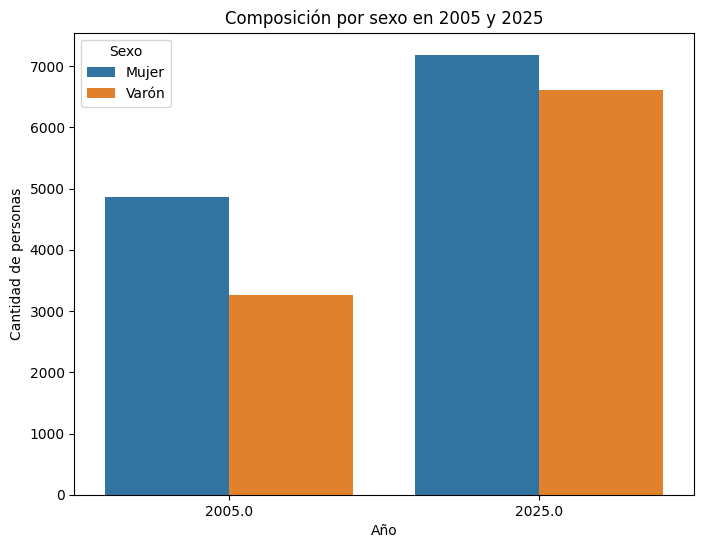

In [42]:
# Mapear los valores de ch04
df_combinado['sexo'] = df_combinado['ch04'].map({1: 'Varón', 2: 'Mujer'})

# Contar la cantidad de casos por sexo y año
sexo_counts = df_combinado.groupby(['ano4', 'sexo']).size().reset_index(name='count')

# Gráfico de barras
plt.figure(figsize=(8,6))
sns.barplot(data=sexo_counts, x='ano4', y='count', hue='sexo')
plt.title("Composición por sexo en 2005 y 2025")
plt.xlabel("Año")
plt.ylabel("Cantidad de personas")
plt.legend(title="Sexo")
plt.show()



In [43]:
# Mapeo de nivel_ed desde texto a números
map_nivel_ed_texto = {
    "Primario incompleto (incluye educación especial)": 1,
    "Primario completo": 2,
    "Secundario incompleto": 3,
    "Secundario completo": 4,
    "Superior y universitario incompleto": 5,
    "Superior y universitario completo": 6,
    "Sin instrucción": 7,
    "Ns/Nr": pd.NA  # poner NA
}

# Mapeo de estado desde texto a números
map_estado_texto = {
    "Entrevista individual no realizada (no respuesta al cuestionario individual)": pd.NA,
    "Ocupado": 1,
    "Desocupado": 2,
    "Inactivo": 3,
    "Menor de 10 años": 4
}

# Aplicarlo al DataFrame
df_combinado['nivel ed'] = df_combinado['nivel_ed'].map(map_nivel_ed_texto)
df_combinado['estado'] = df_combinado['estado'].map(map_estado_texto)


### **Punto 4** 

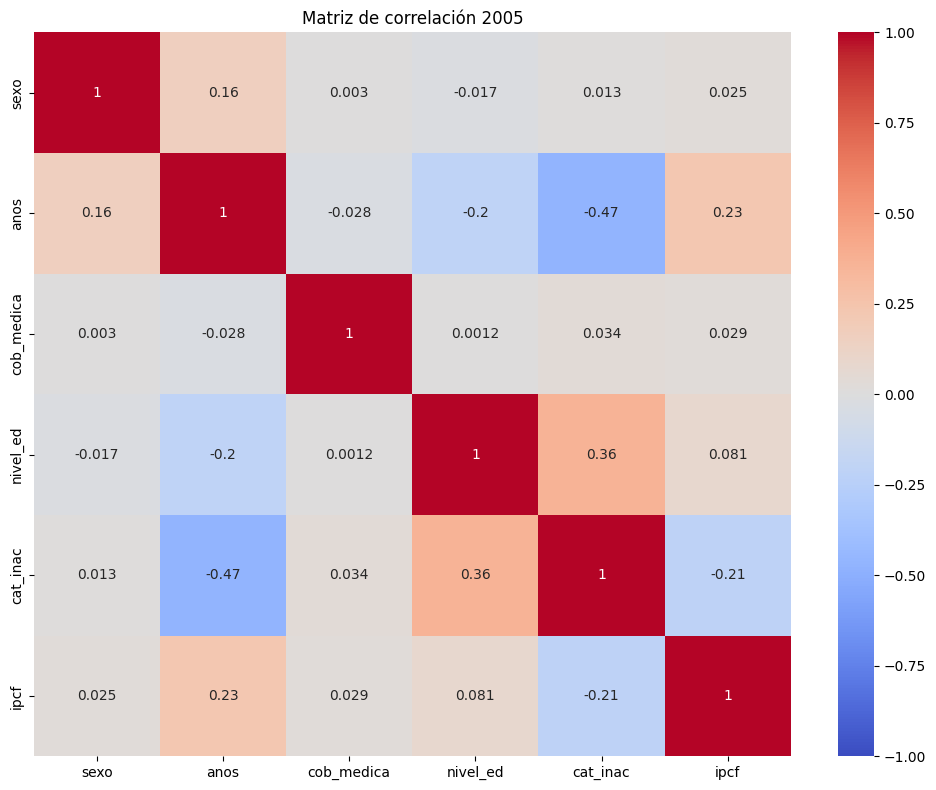

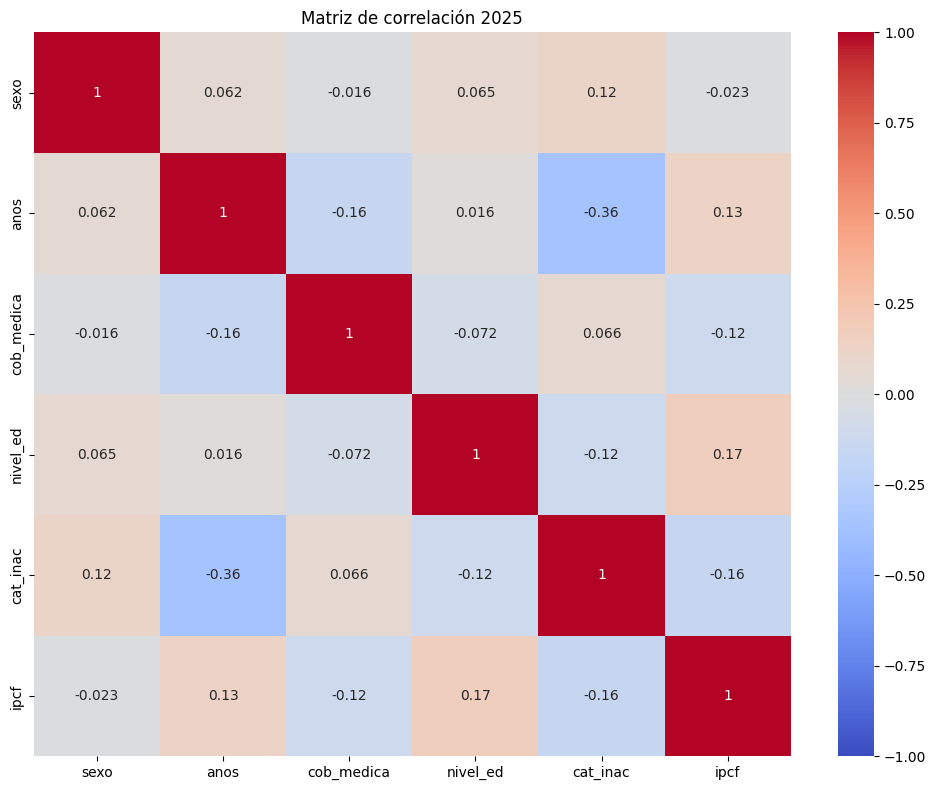

In [44]:
#SIN DUMMIES

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vars_corr = ["ch04", "ch06", "ch07", "ch08", "nivel_ed", "estado", "cat_inac", "ipcf"]
rename_dict = {"ch04": "sexo", "ch06": "anos", "ch07": "estado_civil", "ch08": "cob_medica"}

# --- 2005 ---
df2005 = (
    df_combinado.loc[df_combinado["ano4"] == 2005, vars_corr]
      .rename(columns=rename_dict)
      .copy()
)
df2005["sexo"] = df2005["sexo"].map({1: 0, 2: 1})
df2005["anos"] = pd.to_numeric(df2005["anos"], errors="coerce")  # por si quedó texto tipo “Menos de 1 año”

corr2005 = df2005.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr2005, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación 2005")
plt.tight_layout()
plt.show()

# --- 2025 ---
df2025 = (
    df_combinado.loc[df_combinado["ano4"] == 2025, vars_corr]
      .rename(columns=rename_dict)
      .copy()
)
df2025["sexo"] = df2025["sexo"].map({1: 0, 2: 1})
df2025["anos"] = pd.to_numeric(df2025["anos"], errors="coerce")

corr2025 = df2025.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr2025, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación 2025")
plt.tight_layout()
plt.show()


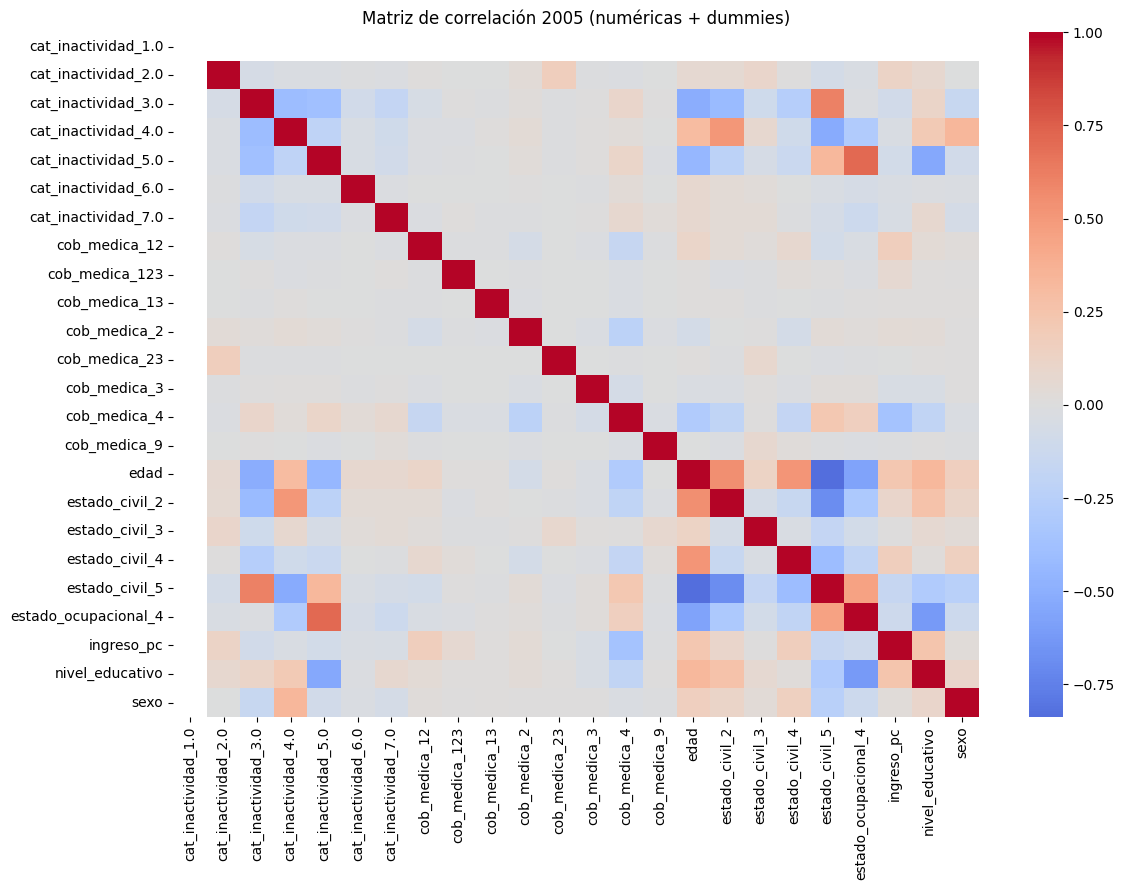

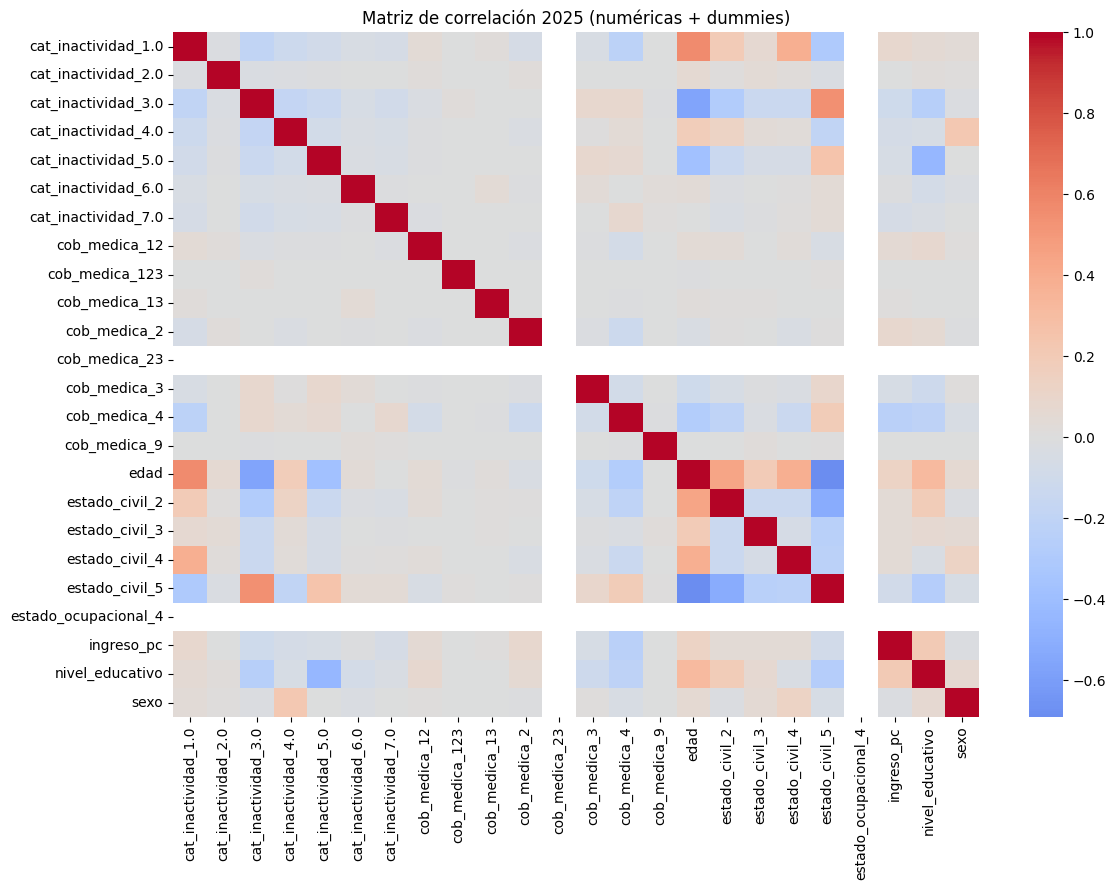

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#CON DUMMIES

# --- Variables de interés y renombres legibles ---
vars_corr = ["ch04","ch06","ch07","ch08","nivel_ed","estado","cat_inac","ipcf"]
rename_dict = {
    "ch04": "sexo",
    "ch06": "edad",
    "ch07": "estado_civil",
    "ch08": "cob_medica",
    "nivel_ed": "nivel_educativo",
    "estado": "estado_ocupacional",
    "cat_inac": "cat_inactividad",
    "ipcf": "ingreso_pc"
}
# ⚠️ sacamos nivel_educativo porque ya es ordinal
cat_cols = ["estado_civil","cob_medica","estado_ocupacional","cat_inactividad"]

def preparar_para_corr(df, year):
    # subset + rename
    d = (df.loc[df["ano4"] == year, vars_corr]
           .rename(columns=rename_dict)
           .copy())

    # --- limpieza mínima y tipado ---
    # edad puede venir como texto: "Menos de 1 año", "98 y más años"
    d["edad"] = (
        d["edad"]
        .replace({"Menos de 1 año": 0, "98 y más años": 98})
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Float64")
    )

    # sexo 1=varón, 2=mujer -> dummy 0/1
    d["sexo"] = d["sexo"].map({1: 0, 2: 1}).astype("Float64")

    # ipcf (ingreso per cápita) a numérico
    d["ingreso_pc"] = pd.to_numeric(d["ingreso_pc"], errors="coerce").astype("Float64")

    # nivel educativo: robust ordinal mapping
    nivel_map = {"7": 1, "1": 2, "2": 3, "3": 4, "4": 5, "5": 6, "6": 7}
    d["nivel_educativo"] = d["nivel_educativo"].astype(str).str.strip()
    d.loc[~d["nivel_educativo"].isin(nivel_map.keys()), "nivel_educativo"] = pd.NA
    d["nivel_educativo"] = d["nivel_educativo"].map(nivel_map).astype("Float64")

    # pasar categóricas a string limpio (si vienen con objetos/códigos)
    for c in cat_cols:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip().replace(
                {"nan": pd.NA, "Ns./Nr.": pd.NA, "Ns/Nr": pd.NA, "": pd.NA}
            )

    # crear dummies (drop_first para evitar colinealidad)
    d = pd.get_dummies(d, columns=[c for c in cat_cols if c in d.columns], drop_first=True)

    return d

# preparar ambos años
df2005 = preparar_para_corr(df_combinado, 2005)
df2025 = preparar_para_corr(df_combinado, 2025)

# alinear columnas (por si algún año no tiene alguna categoría)
df2005, df2025 = df2005.align(df2025, join="outer", axis=1, fill_value=0)

# calcular correlaciones
corr2005 = df2005.corr(numeric_only=True)
corr2025 = df2025.corr(numeric_only=True)

# graficar
plt.figure(figsize=(12,9))
sns.heatmap(corr2005, cmap="coolwarm", center=0)
plt.title("Matriz de correlación 2005 (numéricas + dummies)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,9))
sns.heatmap(corr2025, cmap="coolwarm", center=0)
plt.title("Matriz de correlación 2025 (numéricas + dummies)")
plt.tight_layout()
plt.show()


## **Parte III: Conociendo a los pobres y no pobres** 

### **Punto 5** 

In [46]:
# Usamos ipcf como proxy de ITF (en tu base combinada es la variable disponible)

# Base con los que no respondieron (ipcf = 0 o NA)
norespondieron = df_combinado[df_combinado["ipcf"].fillna(0) == 0].copy()

# Base con los que respondieron (ipcf distinto de 0)
respondieron = df_combinado[df_combinado["ipcf"].fillna(0) != 0].copy()

print("Cantidad de personas con ipcf = 0 (no respondieron):", norespondieron.shape[0])
print("Cantidad de personas con ipcf ≠ 0 (respondieron):", respondieron.shape[0])

# Guardar como archivos separados (opcional)
norespondieron.to_excel("norespondieron.xlsx", index=False)
respondieron.to_excel("respondieron.xlsx", index=False)


Cantidad de personas con ipcf = 0 (no respondieron): 4568
Cantidad de personas con ipcf ≠ 0 (respondieron): 17368


### **Punto 6** 

In [47]:
import pandas as pd
import numpy as np
import re

# =========================
# PUNTO 6 (robusto a nombres de columnas del Excel)
# =========================

assert "respondieron" in globals(), "No encuentro la base 'respondieron'. Corré el punto 5 antes."

resp = respondieron.copy()

# 1) Derivar columnas limpias para merge: sexo_num y edad
# sexo_num: desde ch04 (num) o desde 'sexo' textual
if "ch04" in resp.columns:
    resp["sexo_num"] = pd.to_numeric(resp["ch04"], errors="coerce").astype("Int64")
elif "sexo" in resp.columns:
    resp["sexo_num"] = resp["sexo"].map({"Varón": 1, "Mujer": 2})
    resp["sexo_num"] = pd.to_numeric(resp["sexo_num"], errors="coerce").astype("Int64")
else:
    raise KeyError("No encuentro 'ch04' ni 'sexo' para derivar el sexo numérico (1=varón, 2=mujer).")

# edad: desde ch06 (o 'anos' si la hubieras creado antes)
if "ch06" in resp.columns:
    edad_src = resp["ch06"]
elif "anos" in resp.columns:
    edad_src = resp["anos"]
else:
    raise KeyError("No encuentro 'ch06' ni 'anos' para derivar la edad.")

resp["edad"] = (
    edad_src.replace({"Menos de 1 año": 0, "98 y más años": 98})
            .pipe(pd.to_numeric, errors="coerce")
            .astype("Int64")
)

# 2) Cargar tabla de adulto equivalente con detección flexible de encabezados
def _find_col(cols, candidates_regex):
    cols_lc = {c: c for c in cols}  # identidad
    # probar match por regex en lower
    for c in cols:
        if re.search(candidates_regex, str(c), flags=re.IGNORECASE):
            return c
    return None

def cargar_tabla_equiv_flexible(path="tabla_adulto_equiv.xlsx"):
    try:
        te = pd.read_excel(path)
        # Intentar detectar columnas por patrones
        col_sexo = _find_col(
            te.columns,
            r"\b(sexo|sex|género|genero|ch04)\b"
        )
        col_edad = _find_col(
            te.columns,
            r"\b(edad|age|años|anos|año|anio|ch06)\b"
        )
        col_equiv = _find_col(
            te.columns,
            r"(adulto[_\s]?equiv|equiv|valor[_\s]?equiv|adulto equivalente|ae)"
        )

        if not col_sexo or not col_edad or not col_equiv:
            raise ValueError(
                "No pude detectar columnas de sexo/edad/adulto_equiv en el Excel. "
                f"Columns={list(te.columns)}"
            )

        te = te.rename(columns={
            col_sexo: "sexo",
            col_edad: "edad",
            col_equiv: "adulto_equiv"
        })

        te["sexo"] = pd.to_numeric(te["sexo"], errors="coerce").astype("Int64")
        te["edad"] = (
            te["edad"]
              .replace({"Menos de 1 año": 0, "98 y más años": 98})
              .pipe(pd.to_numeric, errors="coerce")
              .astype("Int64")
        )
        te["adulto_equiv"] = pd.to_numeric(te["adulto_equiv"], errors="coerce")
        return te[["sexo","edad","adulto_equiv"]].dropna(subset=["sexo","edad"])
    except Exception as e:
        print("ℹ️ No pude usar el Excel de equivalencias:", e)
        print("   -> Uso un fallback simplificado generado en memoria (aprox.).")
        filas = []
        for sexo in [1, 2]:
            for edad in range(0, 99):
                if edad <= 5:
                    equiv = 0.60
                elif edad <= 12:
                    equiv = 0.70
                elif edad <= 17:
                    equiv = 0.90
                elif edad <= 59:
                    equiv = 1.00 if sexo == 1 else 0.77
                else:
                    equiv = 0.88
                filas.append({"sexo": sexo, "edad": edad, "adulto_equiv": equiv})
        return pd.DataFrame(filas)

tabla_equiv = cargar_tabla_equiv_flexible()

# 3) Merge por (sexo_num, edad)
resp = resp.merge(
    tabla_equiv.rename(columns={"sexo": "sexo_num"}),
    how="left",
    on=["sexo_num", "edad"]
)

falt = resp["adulto_equiv"].isna().sum()
if falt > 0:
    print(f"⚠️ {falt} filas sin 'adulto_equiv' (sexo/edad fuera de tabla). Imputo 1.0 por defecto.")
    resp["adulto_equiv"] = resp["adulto_equiv"].fillna(1.0)

# 4) Sumar por hogar -> ad_equiv_hogar (detecta clave de hogar)
candidatos_hogar = [
    ["codusu","nro_hogar"],  # típico EPH
    ["codusu"],
    ["id_hogar"],
]
keys = None
for ks in candidatos_hogar:
    if set(ks).issubset(resp.columns):
        keys = ks
        break
if keys is None:
    print("ℹ️ No encontré columnas de hogar (p.ej. 'codusu', 'nro_hogar'). "
          "Creo un id sintético por fila (equivale a hogar unipersonal).")
    resp["__hogar_sint__"] = resp.index
    keys = ["__hogar_sint__"]

resp["ad_equiv_hogar"] = resp.groupby(keys)["adulto_equiv"].transform("sum")

# 5) Actualizar 'respondieron'
respondieron = resp.copy()

# Chequeo final
print(respondieron[["sexo_num","edad","adulto_equiv","ad_equiv_hogar"]].head())
print("✅ Punto 6 listo: adulto_equiv agregado y ad_equiv_hogar calculado.")


ℹ️ No pude usar el Excel de equivalencias: [Errno 2] No such file or directory: 'tabla_adulto_equiv.xlsx'
   -> Uso un fallback simplificado generado en memoria (aprox.).
⚠️ 266 filas sin 'adulto_equiv' (sexo/edad fuera de tabla). Imputo 1.0 por defecto.
ℹ️ No encontré columnas de hogar (p.ej. 'codusu', 'nro_hogar'). Creo un id sintético por fila (equivale a hogar unipersonal).
   sexo_num  edad  adulto_equiv  ad_equiv_hogar
0         1     4          0.60            0.60
1         2     1          0.60            0.60
2         2    78          0.88            0.88
3         1    16          0.90            0.90
4         1    -1          1.00            1.00
✅ Punto 6 listo: adulto_equiv agregado y ad_equiv_hogar calculado.


In [48]:
# Limpiar sexo/edad en respondieron para reducir NAs
respondieron["ch04"] = (
    respondieron["ch04"]
      .replace({"Varón": 1, "Mujer": 2})
      .pipe(pd.to_numeric, errors="coerce")
      .astype("Int64")
)

respondieron["ch06"] = (
    respondieron["ch06"]
      .replace({
          "Menos de 1 año": 0,
          "98 y más años": 98,
          "98 y mas años": 98,
          "98+": 98
      })
      .pipe(pd.to_numeric, errors="coerce")
      .astype("Int64")
)

print("NAs en ch04:", respondieron["ch04"].isna().sum())
print("NAs en ch06:", respondieron["ch06"].isna().sum())

NAs en ch04: 0
NAs en ch06: 0


In [49]:
import pandas as pd

# Asegurar que tengamos 'adulto_equiv'
if "adulto_equiv" not in respondieron.columns:
    raise RuntimeError("Falta 'adulto_equiv'. Corré antes el bloque que lo genera (Punto 6).")

resp = respondieron.copy()

# 1) Detectar claves de hogar (case-insensitive)
cols_lower = {c.lower(): c for c in resp.columns}
candidatos = [
    ["codusu", "nro_hogar"],
    ["codusu"],
    ["id_hogar"],
    ["id_hog", "nro_hogar"],
    ["cod_hogar"],
]
keys = None
for ks in candidatos:
    if all(k in cols_lower for k in ks):
        keys = [cols_lower[k] for k in ks]  # usar el nombre real con el case original
        break

# 2) Si no hay claves, crear un id sintético y agrupar
if keys is None:
    print("ℹ️ No hay columnas de hogar detectables; uso identificador sintético por fila.")
    resp["__hogar_sint__"] = resp.index
    keys = ["__hogar_sint__"]

# 3) Calcular ad_equiv_hogar por groupby-transform
resp["ad_equiv_hogar"] = resp.groupby(keys)["adulto_equiv"].transform("sum")

# 4) Guardar de vuelta
respondieron = resp

# 5) Chequeo
print("Columnas hogar usadas:", keys)
print(respondieron[["adulto_equiv","ad_equiv_hogar"]].head())
print("✅ 'ad_equiv_hogar' creado.")


ℹ️ No hay columnas de hogar detectables; uso identificador sintético por fila.
Columnas hogar usadas: ['__hogar_sint__']
   adulto_equiv  ad_equiv_hogar
0          0.60            0.60
1          0.60            0.60
2          0.88            0.88
3          0.90            0.90
4          1.00            1.00
✅ 'ad_equiv_hogar' creado.


### **Punto 7** 

In [50]:
# 1) Asegurar tipos numéricos (por las dudas)
respondieron["ad_equiv_hogar"] = pd.to_numeric(respondieron["ad_equiv_hogar"], errors="coerce")
respondieron["ano4"] = pd.to_numeric(respondieron["ano4"], errors="coerce")

# 2) Calcular ingreso_necesario (tu bloque)
CBT_2025 = 365_177.0
CBT_2005 = 205.07
respondieron["ingreso_necesario"] = np.where(
    respondieron["ano4"] == 2025,
    respondieron["ad_equiv_hogar"] * CBT_2025,
    respondieron["ad_equiv_hogar"] * CBT_2005
)

# 3) Vistazo rápido
print(respondieron[["ano4","ad_equiv_hogar","ingreso_necesario"]].head())
print(respondieron.groupby("ano4")["ingreso_necesario"].describe().round(2))


     ano4  ad_equiv_hogar  ingreso_necesario
0  2005.0            0.60           123.0420
1  2005.0            0.60           123.0420
2  2005.0            0.88           180.4616
3  2005.0            0.90           184.5630
4  2005.0            1.00           205.0700
         count       mean       std        min        25%        50%  \
ano4                                                                   
2005.0  8028.0     163.30     24.62     123.04     143.55     157.90   
2025.0  9340.0  310384.03  43225.97  219106.20  281186.29  321355.76   

              75%        max  
ano4                          
2005.0     180.46     205.07  
2025.0  365177.00  365177.00  


### **Punto 8** 

In [51]:
# Asegurar tipos
respondieron["ipcf"] = pd.to_numeric(respondieron["ipcf"], errors="coerce")
respondieron["ingreso_necesario"] = pd.to_numeric(respondieron["ingreso_necesario"], errors="coerce")

# Variable pobre (proxy con ipcf, ver nota metodológica)
respondieron["pobre"] = (respondieron["ipcf"] < respondieron["ingreso_necesario"]).astype(int)

# Conteo por año (denominador = cantidad con ipcf válido en 'respondieron')
res = (respondieron
       .dropna(subset=["ipcf","ingreso_necesario"])
       .groupby("ano4")
       .agg(n_pobres=("pobre","sum"),
            n_obs=("pobre","size"))
       .reset_index())
res["pct_pobres"] = (res["n_pobres"] / res["n_obs"] * 100).round(2)

print("Pobreza (conteo y % sobre la muestra con ipcf válido):")
print(res)


Pobreza (conteo y % sobre la muestra con ipcf válido):
     ano4  n_pobres  n_obs  pct_pobres
0  2005.0         0   8028        0.00
1  2025.0      3471   9340       37.16


### **Punto 9** 

Estadísticas descriptivas de 'pobre' por año:
         count   mean    std  min  25%  50%  75%  max
ano4                                                 
2005.0  8028.0  0.000  0.000  0.0  0.0  0.0  0.0  0.0
2025.0  9340.0  0.372  0.483  0.0  0.0  0.0  1.0  1.0


C:\Users\loloa\AppData\Local\Temp\ipykernel_10116\312561244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pobre_pct, x="ano4", y="pobre", palette="Set2")


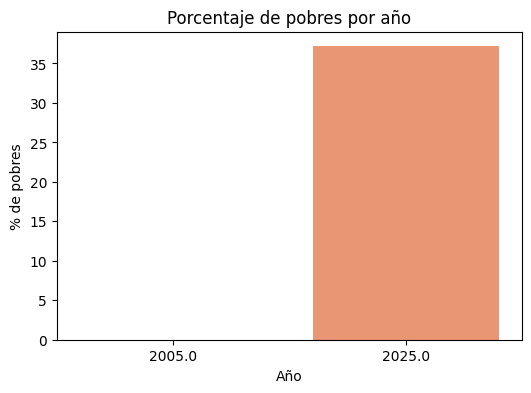

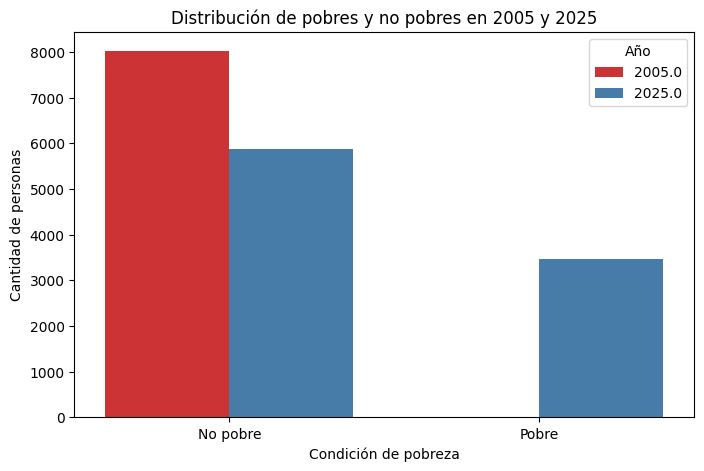

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Tabla descriptiva ---
desc_pobre = respondieron.groupby("ano4")["pobre"].describe().round(3)
print("Estadísticas descriptivas de 'pobre' por año:")
print(desc_pobre)

# --- Gráfico 1: Barras con % de pobres por año ---
pobre_pct = respondieron.groupby("ano4")["pobre"].mean().reset_index()
pobre_pct["pobre"] = pobre_pct["pobre"] * 100

plt.figure(figsize=(6,4))
sns.barplot(data=pobre_pct, x="ano4", y="pobre", palette="Set2")
plt.ylabel("% de pobres")
plt.xlabel("Año")
plt.title("Porcentaje de pobres por año")
plt.show()

# --- Gráfico 2: Countplot pobreza (0=No pobre, 1=Pobre) por año ---
plt.figure(figsize=(8,5))
sns.countplot(data=respondieron, x="pobre", hue="ano4", palette="Set1")
plt.xticks([0,1], ["No pobre", "Pobre"])
plt.xlabel("Condición de pobreza")
plt.ylabel("Cantidad de personas")
plt.title("Distribución de pobres y no pobres en 2005 y 2025")
plt.legend(title="Año")
plt.show()
